# 07 — Sharpened Pipeline: Variance Filter + Random Forest

Keep top 20K variance genes, replace LR with RF.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from gtex_biomarkers.config import Config
from gtex_biomarkers.data import load_cache, variance_filter
from gtex_biomarkers.labels import discover_tissue_category_pairs
from gtex_biomarkers.models import make_rf_model
from gtex_biomarkers.utils import run_all_tissue_models_parallel
from gtex_biomarkers.evaluation import (
    plot_roc_grid, plot_pr_grid, plot_cm_grid, plot_boxplot_grid,
)

Config.ensure_dirs()

# Load cached data (run notebook 01 first)
X_wb, blood_subjid, _, df_meta_url, _ = load_cache()

Loaded cache from /Users/rsinha/Library/CloudStorage/OneDrive-SanfordBurnhamPrebysMedicalDiscoveryInstitute/Desktop/gtex_gene_expression/data/cache/processed_data.pkl
  X_wb: 803 samples × 59033 genes


## Variance Filter — Top 20K Genes

Filtered: 59,033 → 20,000 genes


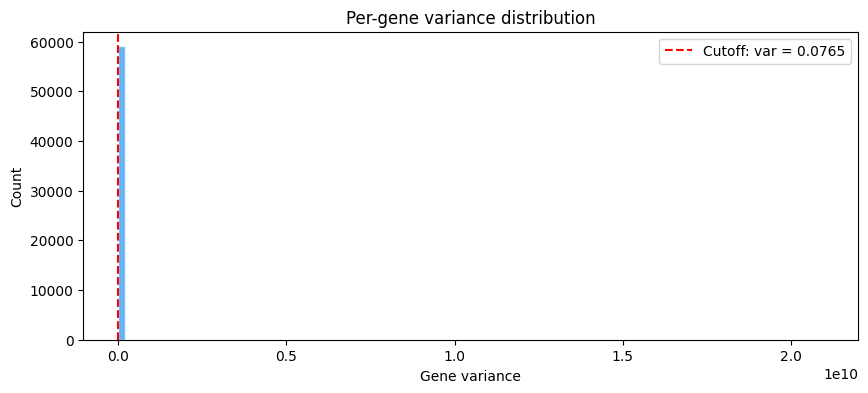

In [2]:
X_wb_var, gene_var = variance_filter(X_wb)
print(f"Filtered: {X_wb.shape[1]:,} → {X_wb_var.shape[1]:,} genes")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(gene_var.values, bins=100, color="#2196F3", alpha=0.7, edgecolor="white")
ax.axvline(gene_var.iloc[Config.N_TOP_VAR_GENES - 1], color="red", ls="--", lw=1.5,
           label=f"Cutoff: var = {gene_var.iloc[Config.N_TOP_VAR_GENES - 1]:.4f}")
ax.set_xlabel("Gene variance"); ax.set_ylabel("Count")
ax.set_title("Per-gene variance distribution"); ax.legend()
fig.savefig(Config.FIGURES_DIR / "gene_variance_distribution.pdf", bbox_inches="tight")
plt.show()

## Run RF Models (Parallelized by Tissue)

In [3]:
pairs_df = discover_tissue_category_pairs(df_meta_url)

rf_results, rf_summary = run_all_tissue_models_parallel(
    pairs_df, df_meta_url, blood_subjid, X_wb_var, make_rf_model,
    save_features=True
)
rf_summary.to_csv(Config.TABLES_DIR / "cv_results_all_tissue_rf.csv", index=False)
print(f"Completed {len(rf_results)} RF models")
display(rf_summary)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done   6 out of  19 | elapsed:  7.4min remaining: 16.0min
[Parallel(n_jobs=-1)]: Done   8 out of  19 | elapsed:  7.5min remaining: 10.3min
[Parallel(n_jobs=-1)]: Done  10 out of  19 | elapsed:  9.0min remaining:  8.1min
[Parallel(n_jobs=-1)]: Done  12 out of  19 | elapsed:  9.5min remaining:  5.5min
[Parallel(n_jobs=-1)]: Done  14 out of  19 | elapsed:  9.7min remaining:  3.4min
[Parallel(n_jobs=-1)]: Done  16 out of  19 | elapsed: 10.7min remaining:  2.0min


Completed 53 RF models


[Parallel(n_jobs=-1)]: Done  19 out of  19 | elapsed: 14.7min finished


,tissue,category,mean_auc,std_auc,optimal_threshold
15,Breast - Mammary Tissue,gynecomastoid,0.881665,0.054384,0.348
18,Breast - Mammary Tissue,atrophy,0.841520,0.028483,0.056
47,Spleen,congestion,0.826177,0.032293,0.854
30,Liver,cirrhosis,0.804298,0.096935,0.206
16,Breast - Mammary Tissue,hyperplasia,0.752899,0.081496,0.352
37,Lung,pneumonia,0.736086,0.017557,0.106
44,Pancreas,saponification,0.730258,0.026908,0.434
48,Testis,spermatogenesis,0.711798,0.086618,0.970
40,Muscle - Skeletal,atrophy,0.693750,0.093076,0.856
28,Liver,congestion,0.683426,0.030356,0.636


## RF Evaluation Plots

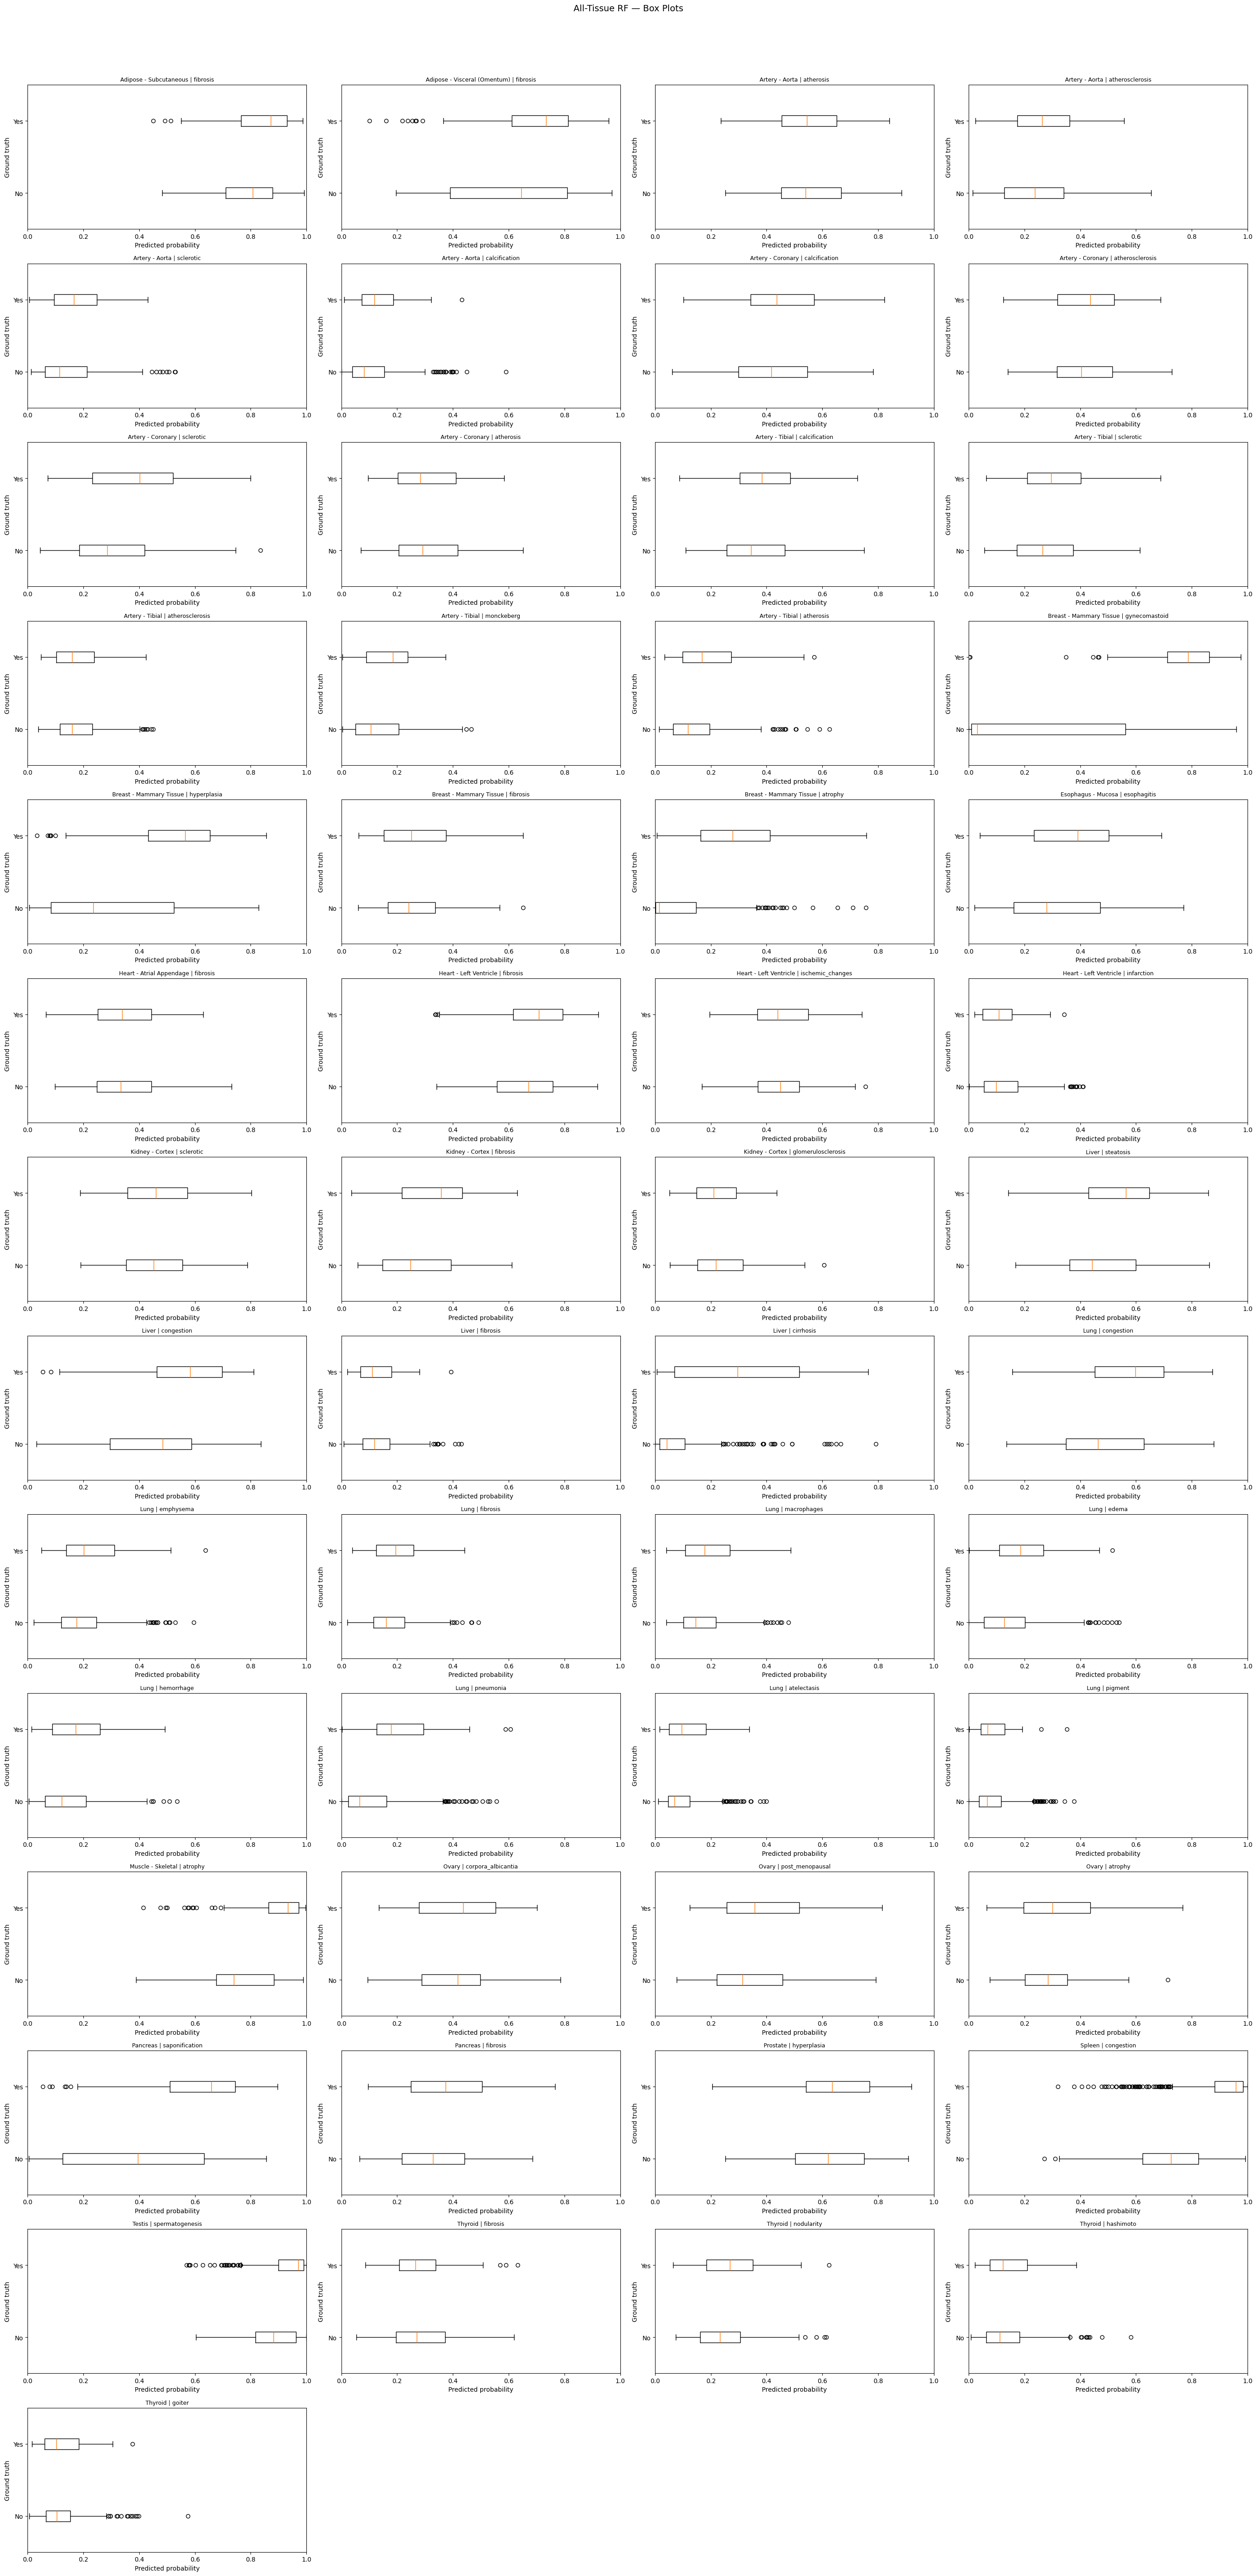

In [4]:
plot_roc_grid(rf_results,
             suptitle="All-Tissue RF — ROC (20K var-filtered)",
             save_path=Config.FIGURES_DIR / "roc_all_tissue_rf.pdf")
plot_boxplot_grid(rf_results,
                  suptitle="All-Tissue RF — Box Plots",
                  save_path=Config.FIGURES_DIR / "boxplot_all_tissue_rf.pdf")

## Feature Importances — Per-Fold & Aggregated

Extract per-fold selected genes and RF Gini importances from every model.
Produces two tables consumed by downstream notebooks (NB10+):
- **`rf_selected_features.csv`** — per-fold detail (tissue, category, fold, gene, rf_importance)
- **`rf_feature_importances.csv`** — aggregated (tissue, category, gene, mean_importance, n_folds_selected)

In [5]:
# --- Per-fold detail table ---
rows_detail = []
for tag, res in rf_results.items():
    if "feature_info" not in res:
        continue
    for fi in res["feature_info"]:
        for gene in fi["selected_genes"]:
            rows_detail.append({
                "tissue": res["tissue"],
                "category": res["category"],
                "fold": fi["fold"],
                "gene": gene,
                "rf_importance": fi["rf_importances"].get(gene, 0.0),
            })

df_detail = pd.DataFrame(rows_detail)
df_detail.to_csv(Config.TABLES_DIR / "rf_selected_features.csv", index=False)
print(f"Per-fold detail: {len(df_detail):,} rows "
      f"({df_detail[['tissue','category']].drop_duplicates().shape[0]} models × 5 folds × {Config.TOP_K_FEATURES} genes)")

# --- Aggregated table ---
df_agg = (
    df_detail.groupby(["tissue", "category", "gene"])
    .agg(
        mean_importance=("rf_importance", "mean"),
        std_importance=("rf_importance", "std"),
        n_folds_selected=("fold", "nunique"),
    )
    .reset_index()
    .sort_values(["tissue", "category", "mean_importance"], ascending=[True, True, False])
)
df_agg.to_csv(Config.TABLES_DIR / "rf_feature_importances.csv", index=False)
print(f"Aggregated: {len(df_agg):,} unique (tissue, category, gene) entries")
print(f"\nConsensus genes (≥3/5 folds) per model:")
consensus = df_agg[df_agg["n_folds_selected"] >= 3]
print(consensus.groupby(["tissue", "category"]).size().describe())
display(df_agg.head(20))

Per-fold detail: 26,500 rows (53 models × 5 folds × 100 genes)
Aggregated: 16,163 unique (tissue, category, gene) entries

Consensus genes (≥3/5 folds) per model:
count    53.000000
mean     50.905660
std      13.521015
min      26.000000
25%      42.000000
50%      50.000000
75%      57.000000
max      82.000000
dtype: float64


,tissue,category,gene,mean_importance,std_importance,n_folds_selected
100,Adipose - Subcutaneous,fibrosis,ENSG00000158525.16,0.029845,NaN,1
149,Adipose - Subcutaneous,fibrosis,ENSG00000175084.13,0.029401,NaN,1
1,Adipose - Subcutaneous,fibrosis,ENSG00000005882.12,0.022880,NaN,1
84,Adipose - Subcutaneous,fibrosis,ENSG00000140986.8,0.022108,0.009579,2
194,Adipose - Subcutaneous,fibrosis,ENSG00000204463.14,0.022061,0.008472,4
188,Adipose - Subcutaneous,fibrosis,ENSG00000198157.11,0.020580,0.009524,3
271,Adipose - Subcutaneous,fibrosis,ENSG00000271046.1,0.020227,0.001911,2
253,Adipose - Subcutaneous,fibrosis,ENSG00000257275.6,0.018766,0.008071,5
207,Adipose - Subcutaneous,fibrosis,ENSG00000213866.3,0.018051,0.001513,3
69,Adipose - Subcutaneous,fibrosis,ENSG00000130165.10,0.016962,NaN,1
